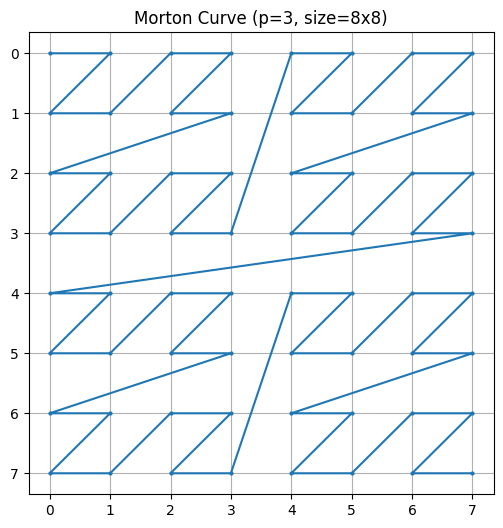

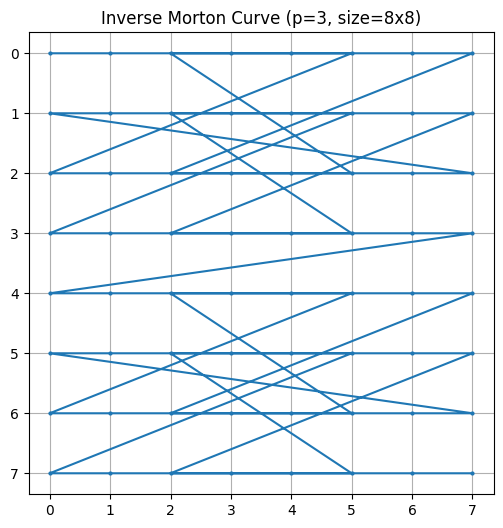

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# Morton index helpers (from previous answer)
# ----------------------------------------------------------------------
def part1by1(n):
    n &= 0x0000ffff
    n = (n | (n << 8)) & 0x00FF00FF
    n = (n | (n << 4)) & 0x0F0F0F0F
    n = (n | (n << 2)) & 0x33333333
    n = (n | (n << 1)) & 0x55555555
    return n

def morton2D(x, y):
    return (part1by1(y) << 1) | part1by1(x)

def get_morton_flat_indices(p):
    size = 2 ** p
    morton = torch.zeros(size * size, dtype=torch.long)
    idx = 0
    for y in range(size):
        for x in range(size):
            morton[idx] = morton2D(x, y)
            idx += 1
    return torch.argsort(morton)

def get_inverse_morton_indices(p):
    morton = get_morton_flat_indices(p)
    inverse = torch.empty_like(morton)
    inverse[morton] = torch.arange(morton.numel(), device=morton.device)
    return inverse

# ----------------------------------------------------------------------
# Visualization 
# ----------------------------------------------------------------------
def visualize_morton_curve(p, use_inverse=False):
    """
    Visualize Morton curve for grid 2^p x 2^p.
    """
    size = 2 ** p

    if use_inverse:
        ordering = get_inverse_morton_indices(p)
    else:
        ordering = get_morton_flat_indices(p)

    # Convert flat indices back to 2D coords
    xs = []
    ys = []
    for idx in ordering:
        i = idx.item()
        y = i // size
        x = i % size
        xs.append(x)
        ys.append(y)

    # Plot
    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, "-o", markersize=2)
    plt.title(f"{'Inverse ' if use_inverse else ''}Morton Curve (p={p}, size={size}x{size})")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.show()

# ----------------------------------------------------------------------
# Test
# ----------------------------------------------------------------------
if __name__ == "__main__":
    visualize_morton_curve(3)           # 正向 Morton
    visualize_morton_curve(3, True)     # 逆向 Morton